# Evaluación 2

---



**Autores:**

1. Brian Chávez
2. Carlos Soto





**Correos Electrónicos:**


1. bria.chavez@duocuc.cl
2. car.sotoa@duocuc.cl


**Fecha de Creación:** Enero 2026

**Versión:** 1.0  



---

## Descripción

Este notebook corresponde al desarrollo de la entrega 2 de la asignatura Minería de Datos en el TAV de DuocUC - Sede Concepción

---

## Requisitos de Software

Este notebook fue desarrollado con Python 3.9. A continuación se listan las bibliotecas necesarias:

-
    pandas
-
    numpy
-
    matplotlib
-
    seaborn

Para verificar la versión instalada ejecutar usando el siguiente comando, usando la librería de la cual quieres saber la versión:

```bash
import pandas as pd
print(pd.__version__)
````

## Requisitos del notebook
1. Identificación de valores duplicados y su correspondiente interpretación del hallazgo.
2. Identificación de valores nulos y su correspondiente interpretación del hallazgo.
3. Identificación de valores atípicos y su correspondiente interpretación del hallazgo.
4. Obtención de columnas hora y mes.
5. Transformación cíclica de las variables de hora y mes.
6. Aplicar en el pipeline, correctamente, la tarea de tratamiento de atípicos.
7. Aplicar en el pipeline, correctamente, la tarea de imputación de nulos de las variables cuantitativas.
8. Aplicar en el pipeline, correctamente, la tarea de imputación de nulos de las variables cualitativas.
9. Aplicar en el pipeline, correctamente, la tarea de transformación de las variables cualitativas.
10. Aplicar en el pipeline, correctamente, la tarea de estandarización.
11. Creación de las ventanas de tiempo.
12. Justificación de los criterios y variables incluidas en la generación de las ventanas de tiempo.
13. Mostrar la composición del pipeline.
14. Mostrar el resultado de la fase, es decir, el conjunto de datos preparado.
15. Guardar en un CSV el conjunto de datos preparado.
16. Uso de lenguaje técnico adecuado en las interpretaciones de los hallazgos.

## Penalizaciones

- Ausencia de autores en el notebook (10%)
- Ausencia de uso de pipeline (50%)
- Faltas a la ortografía y redacción en el notebook (10%)
- Faltas en nombre del notebook y archivo CSV de salida (10%)


In [ ]:
!wget https://raw.githubusercontent.com/JaznaLaProfe/datos/refs/heads/main/data_clima/data_clima_2025_final.csv

--2026-01-13 22:33:41--  https://raw.githubusercontent.com/JaznaLaProfe/datos/refs/heads/main/data_clima/data_clima_2025_final.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4527300 (4.3M) [text/plain]
Saving to: ‘data_clima_2025_final.csv’

data_clima_2025_fin 100%[===================>]   4.32M  --.-KB/s    in 0.07s   

2026-01-13 22:33:42 (60.5 MB/s) - ‘data_clima_2025_final.csv’ saved [4527300/4527300]



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer


In [ ]:
data = pd.read_csv('data_clima_2025_final.csv')
data.head()



,date,temperature_2m,relative_humidity_2m,apparent_temperature,precipitation,cloud_cover,wind_speed_10m,wind_direction_10m,rain,is_day,sunshine_duration,Localidad,latitud,longitud,is_rainy_hour
0,2025-01-01 03:00:00+00:00,15.1,72.053330,13.451475,0.0,0.0,11.609651,187.12492,0.0,0.0,0.0,"Concepción, Chile",-36.82707,-73.050206,0
1,2025-01-01 04:00:00+00:00,14.9,64.437440,12.787600,0.0,0.0,11.341428,179.09064,0.0,0.0,0.0,"Concepción, Chile",-36.82707,-73.050206,0
2,2025-01-01 05:00:00+00:00,14.4,63.023464,12.131762,0.0,0.0,11.032987,174.38250,0.0,0.0,0.0,"Concepción, Chile",-36.82707,-73.050206,0
3,2025-01-01 06:00:00+00:00,13.9,65.991730,11.714258,0.0,0.0,10.805999,178.09090,0.0,0.0,0.0,"Concepción, Chile",-36.82707,-73.050206,0
4,2025-01-01 07:00:00+00:00,13.4,70.770430,11.426943,0.0,0.0,10.299397,185.01303,0.0,0.0,0.0,"Concepción, Chile",-36.82707,-73.050206,0


#1. Identificación de valores duplicados y su correspondiente interpretación del hallazgo.

## Revisión

In [ ]:
# Recorremos todas las columnas del DataFrame
for columna in data.columns:
    # Imprimimos el nombre de la columna y la cantidad de filas duplicadas en esa columna

    # {columna:<27} → Formatea el nombre de la columna:
    # - < : alineación a la izquierda
    # - 27: ancho mínimo de 27 caracteres (rellena con espacios si el nombre es más corto)

    # df[columna].duplicated().sum():
    # - df[columna].duplicated() genera una serie booleana donde True = valor repetido (después de su primera aparición)
    # - .sum() cuenta los True, es decir, la cantidad de duplicados en esa columna

    print(f"{columna:<27} ----> {data[columna].duplicated().sum()}")

date                        ----> 24768
temperature_2m              ----> 31970
relative_humidity_2m        ----> 7772
apparent_temperature        ----> 42
precipitation               ----> 32931
cloud_cover                 ----> 32923
wind_speed_10m              ----> 25875
wind_direction_10m          ----> 19845
rain                        ----> 32905
is_day                      ----> 33022
sunshine_duration           ----> 30091
Localidad                   ----> 33020
latitud                     ----> 33020
longitud                    ----> 33020
is_rainy_hour               ----> 33022


Se pueden ver que hay datos duplicados, pero se hizo un analisis a una mayor profundidad para ver si estos son duplicados a nivel de fila.

In [ ]:
# Duplicados por columnas individuales
duplicados_por_columna = {
    col: data[col].duplicated().sum()
    for col in data.columns
}

# Duplicados por fila completa
duplicados_por_fila = data.duplicated().sum()

print("Duplicados por fila completa:", duplicados_por_fila)


Duplicados por fila completa: 0


Aunque existen valores repetidos en columnas individuales (por ejemplo, mediciones similares en distintas horas), la combinación completa de todas las variables por registro es única, principalmente por el atributo temporal.

## Tratamiento

En el caso de que hubieran duplicados se usaria este código para eliminar los duplicados considerando todas las columnas.


In [ ]:
# data_sin_duplicados = data.drop_duplicates()

Y en el caso de que se quisiera eliminar los duplicados de alguna columna en especifico se optaria por algo mas puntual como este código.

In [ ]:
# data_sin_duplicados = data.drop_duplicates(subset=['col1', 'col2'])

## Explicación

¿Por qué es bueno eliminar los duplicados en la preparación de los datos?

Eliminar duplicados mejora la calidad del conjunto de datos al evitar que ciertas observaciones tengan un peso artificialmente mayor en el modelo.
Además, reduce sesgos estadísticos y sobreajuste, permitiendo que el modelo aprenda patrones reales y no repeticiones del mismo registro.

# 2. Identificación de valores nulos y su correspondiente interpretación del hallazgo.


## Revisión

In [ ]:
# Calcular nulos por columna
columnas_con_nulos = data.isna().sum()

# Porcentaje de nulos
porcentaje_nulos = (columnas_con_nulos / data.shape[0]) * 100

# Construir DataFrame con todas las columnas
resultado = pd.DataFrame({
    "Cantidad Nulos": columnas_con_nulos,
    "Porcentaje Nulos (%)": porcentaje_nulos
}).round(2)

# Si no hay nulos en ninguna columna, se crea una condición para que muestre 0
if resultado["Cantidad Nulos"].sum() == 0:
    resultado.loc[:, "Cantidad Nulos"] = 0
    resultado.loc[:, "Porcentaje Nulos (%)"] = 0.0

resultado

,Cantidad Nulos,Porcentaje Nulos (%)
date,0,0.0
temperature_2m,0,0.0
relative_humidity_2m,0,0.0
apparent_temperature,0,0.0
precipitation,0,0.0
cloud_cover,0,0.0
wind_speed_10m,0,0.0
wind_direction_10m,0,0.0
rain,0,0.0
is_day,0,0.0





##Tratamiento

En el caso de que hubieran nulos, es importante tratarlos de la debida forma, siendo diferente para las variables categoricas y para las variables numericas.

En las variables numéricas, los nulos se imputan con la media de cada atributo, preservando la tendencia central sin introducir valores extremos, mientras que el escalado posterior garantiza comparabilidad entre variables.

En las variables categóricas, los nulos se reemplazan por la categoría más frecuente, evitando pérdida de información y permitiendo una codificación coherente mediante one-hot encoding.

##Explicación

La ausencia de valores nulos en el DataFrame significan buenas noticias, ya que garantiza la integridad y completitud de los datos, evitando la necesidad de imputaciones o eliminaciones que podrían sesgar los resultados. Esto permite realizar análisis estadísticos y un posterior modelado con mayor precisión y confianza, asegurando conclusiones más precisas.

Por lo tanto no se van a tratar en esta ocasión.

#3. Identificación de valores atípicos y su correspondiente interpretación del hallazgo


##Revisión

In [ ]:
#Identificación de todos los atípicos
def buscar_atipicos(data : pd.DataFrame, columna : str) -> pd.DataFrame:
  """
  Busca valores atípicos en una columna.
  """
  # Calcular los límites
  Q1 = data[columna].quantile(0.25)
  Q3 = data[columna].quantile(0.75)
  # Calcula rango intercuartilico
  IQR = Q3 - Q1
  limite_inferior = Q1 - 1.5 * IQR
  limite_superior = Q3 + 1.5 * IQR

  # Filtrar outliers
  return data[(data[columna] < limite_inferior) | (data[columna] > limite_superior)]

def obtener_cantidad_atipicos(data : pd.DataFrame, columnas : np.array) -> dict:
  """
  Obtiene la cantidad de atípicos por cada columna.
  """
  total_atipicos = {}
  for columna in data[columnas]:
    atipicos = buscar_atipicos(data, columna)
    total_atipicos[columna] = atipicos.shape[0]
  return total_atipicos
atipicos_por_columna = obtener_cantidad_atipicos(data, data.describe().columns)
atipicos_por_columna
#nos arroja las variables y su cantidad de atípicos

{'temperature_2m': 476,
 'relative_humidity_2m': 130,
 'apparent_temperature': 282,
 'precipitation': 6152,
 'cloud_cover': 0,
 'wind_speed_10m': 1241,
 'wind_direction_10m': 0,
 'rain': 6100,
 'is_day': 0,
 'sunshine_duration': 0,
 'latitud': 8256,
 'longitud': 0,
 'is_rainy_hour': 6100}

##Tratamiento

Al revisar si existen átipicos en las variables, se puede dejar entrever de que existen bastantes variables con átipicos. Pero al conocer el contexto real de algunas de estas variables como podria ser la variable latitud, estos átipicos solo estarían inflando el contador de estos y no presentan información real de la cual se pueda conocer algún tipo de comportamiento.

Se decidió que se va a utilizar la técnica de winsorizer para tratar los átipicos la cual será puesta en el codigo a continuación.


In [ ]:
#Clase del winsorizer, esto se carga antes de ocuparla en el Pipeline
class Winsorizer(BaseEstimator, TransformerMixin):
    def __init__(self, limits=(0.05, 0.05)):
        self.limits = limits

    def fit(self, X, y=None):
        # Guardar nombres si es DataFrame, si no generar nombres genéricos
        if isinstance(X, pd.DataFrame):
            self.columns_ = X.columns
        else:
            self.columns_ = np.arange(X.shape[1])
        return self

    def transform(self, X):
        X = pd.DataFrame(X, columns=self.columns_)
        for col in self.columns_:
            lower = X[col].quantile(self.limits[0])
            upper = X[col].quantile(1 - self.limits[1])
            X[col] = np.clip(X[col], lower, upper)
        return X.values

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            return np.array(self.columns_)
        else:
            return np.array(input_features)

##Explicación

El Winsorizer reduce la influencia de valores extremos reemplazándolos por los percentiles inferior y superior definidos por el código.

Así de esta forma, se conservan todas las observaciones pero limita los átipicos que podrían sesgar estadísticas y afectar el desempeño del modelo final.


# 4. Tratamiento de las variables cuantitativas y cualitativas

### 4.2 Obtención de columnas hora y mes.




La columna date, originalmente de tipo object, se decició convertirla en un formato mas manejable y seccionado por variables.
A partir de esta conversión se extrajeron componentes temporales (hora, mes, día y año), transformando la fecha en variables útiles para el análisis y modelado, posteriormente se utilizarán para la transformación cíclica de las horas.

In [ ]:
# Convertir la columna 'date' a datetime (una sola vez es suficiente)
data['date'] = pd.to_datetime(data['date'])

# Extraer hora
data['hour'] = data['date'].dt.hour

# Extraer mes
data['month'] = data['date'].dt.month

# Extraer día del mes
data['day'] = data['date'].dt.day

# Extraer año
data['year'] = data['date'].dt.year

# Print de prueba
print(data[['date', 'hour', 'day', 'month', 'year']].head(25))




                        date  hour  day  month  year
0  2025-01-01 03:00:00+00:00     3    1      1  2025
1  2025-01-01 04:00:00+00:00     4    1      1  2025
2  2025-01-01 05:00:00+00:00     5    1      1  2025
3  2025-01-01 06:00:00+00:00     6    1      1  2025
4  2025-01-01 07:00:00+00:00     7    1      1  2025
5  2025-01-01 08:00:00+00:00     8    1      1  2025
6  2025-01-01 09:00:00+00:00     9    1      1  2025
7  2025-01-01 10:00:00+00:00    10    1      1  2025
8  2025-01-01 11:00:00+00:00    11    1      1  2025
9  2025-01-01 12:00:00+00:00    12    1      1  2025
10 2025-01-01 13:00:00+00:00    13    1      1  2025
11 2025-01-01 14:00:00+00:00    14    1      1  2025
12 2025-01-01 15:00:00+00:00    15    1      1  2025
13 2025-01-01 16:00:00+00:00    16    1      1  2025
14 2025-01-01 17:00:00+00:00    17    1      1  2025
15 2025-01-01 18:00:00+00:00    18    1      1  2025
16 2025-01-01 19:00:00+00:00    19    1      1  2025
17 2025-01-01 20:00:00+00:00    20    1      1

###4.3 Creación ventanas de tiempo

Para la creación de las ventanas de tiempo se eligieron las siguientes variables en consideración, cada una separadas en cada localidad disponible y tambíen con información respecto a la variable original , al promedio de estas como también el minimo y máximo de las mediciones:

- temperature_2m

  Influye en procesos de condensación y estabilidad atmosférica.


- relative_humidity_2m

  Variable clave en la formación de precipitación.


- cloud_cover

  Indicador directo de nubosidad y sistemas frontales.


Justificación de la ventana de 5 horas:

La ventana temporal de cinco horas se definió para capturar la evolución inmediata de las condiciones atmosféricas previas a la precipitación, considerando que los procesos de acumulación de humedad, variación térmica y desarrollo de nubosidad se manifiestan típicamente en escalas horarias de corto plazo.

Este intervalo representa un equilibrio entre capturar señales relevantes y evitar la incorporación de ruido meteorológico al tener una ventana muy corta de horas.


Se decidió tomar esta data separada por localidades porque cada zona presenta dinámicas climáticas propias, por lo que analizarlas en conjunto podría ocultar patrones locales de precipitación.


Y en la información de las variables se eligió el promedio, como también mínimo y máximo , esto nos permite capturar tanto el comportamiento general como los extremos de las variables, los cuales son clave en la ocurrencia de eventos meteorológicos.




In [ ]:
window = 5

variables_climaticas = [
    'temperature_2m',
    'relative_humidity_2m',
    'cloud_cover'
]

# Asegurar que 'date' sea de tipo datetime y ordenar para operaciones de ventana
data['date'] = pd.to_datetime(data['date'])
# Extraer 'hour', 'month', 'day' para asegurar que estén disponibles en 'data'
data['hour'] = data['date'].dt.hour
data['month'] = data['date'].dt.month
data['day'] = data['date'].dt.day

# Convertir columnas tipo booleano a int para consistencia si se usan como categóricas más tarde
# Asegurar que estas columnas existan antes de intentar convertirlas o usarlas
if 'is_day' in data.columns:
    data['is_day'] = data['is_day'].astype(int)
if 'is_rainy_hour' in data.columns:
    data['is_rainy_hour'] = data['is_rainy_hour'].astype(int)

data = data.sort_values(['Localidad', 'date'])

dfs_por_localidad = {}

for localidad, df_loc_original in data.groupby('Localidad'):
    df_loc_original = df_loc_original.sort_values('date').reset_index(drop=True)

    # Inicializar un nuevo DataFrame para las características procesadas para esta localidad
    # La longitud será original_length - window + 1 después de la ventana
    processed_data_length = len(df_loc_original) - window + 1
    if processed_data_length <= 0:
        continue # Omitir si no hay suficientes datos para la ventana

    # Crear un DataFrame base para almacenar las características procesadas, asegurando que las columnas estén alineadas
    processed_df_loc = pd.DataFrame({
        'Localidad': [localidad] * processed_data_length,
        'month': df_loc_original['month'].iloc[window - 1:].values,
        'day': df_loc_original['day'].iloc[window - 1:].values,
        'hour': df_loc_original['hour'].iloc[window - 1:].values,
        'is_day': df_loc_original['is_day'].iloc[window - 1:].values,
        'is_rainy_hour': df_loc_original['is_rainy_hour'].iloc[window - 1:].values
    })

    for v in variables_climaticas:
        # Valor actual al final de la ventana
        processed_df_loc[f"{v}_actual"] = df_loc_original[v].iloc[window - 1:].values

        # Estadísticas de la ventana rodante
        rolling_stats = df_loc_original[v].rolling(window=window, min_periods=window)
        # Asegurar la alineación tomando valores desde window-1 hasta el final
        processed_df_loc[f"{v}_mean"] = rolling_stats.mean().iloc[window - 1:].values
        processed_df_loc[f"{v}_max"] = rolling_stats.max().iloc[window - 1:].values
        processed_df_loc[f"{v}_min"] = rolling_stats.min().iloc[window - 1:].values

    # Ordenar nuevamente si es necesario, aunque ya debería estar ordenado por componentes de fecha/hora
    dfs_por_localidad[localidad] = processed_df_loc.sort_values(['month', 'day', 'hour']).reset_index(drop=True)

for localidad, df_loc in dfs_por_localidad.items():
    print(f"\nLocalidad: {localidad}")
    display(df_loc.head())

print("\nExample DataFrame Info for Concepción, Chile:")
display(dfs_por_localidad['Concepción, Chile'].info())


Localidad: Concepción, Chile


,Localidad,month,day,hour,is_day,is_rainy_hour,temperature_2m_actual,temperature_2m_mean,temperature_2m_max,temperature_2m_min,relative_humidity_2m_actual,relative_humidity_2m_mean,relative_humidity_2m_max,relative_humidity_2m_min,cloud_cover_actual,cloud_cover_mean,cloud_cover_max,cloud_cover_min
0,"Concepción, Chile",1,1,7,0,0,13.40,14.34,15.1,13.40,70.770430,67.255279,72.053330,63.023464,0.0,0.0,0.0,0.0
1,"Concepción, Chile",1,1,8,0,0,12.90,13.90,14.9,12.90,78.494840,68.543581,78.494840,63.023464,0.0,0.0,0.0,0.0
2,"Concepción, Chile",1,1,9,0,0,12.40,13.40,14.4,12.40,88.190740,73.294241,88.190740,63.023464,0.0,0.0,0.0,0.0
3,"Concepción, Chile",1,1,10,1,0,12.05,12.93,13.9,12.05,92.369934,79.163535,92.369934,65.991730,0.0,0.0,0.0,0.0
4,"Concepción, Chile",1,1,11,1,0,13.35,12.82,13.4,12.05,85.396050,83.044399,92.369934,70.770430,0.0,0.0,0.0,0.0



Localidad: Punta Arenas, Chile


,Localidad,month,day,hour,is_day,is_rainy_hour,temperature_2m_actual,temperature_2m_mean,temperature_2m_max,temperature_2m_min,relative_humidity_2m_actual,relative_humidity_2m_mean,relative_humidity_2m_max,relative_humidity_2m_min,cloud_cover_actual,cloud_cover_mean,cloud_cover_max,cloud_cover_min
0,"Punta Arenas, Chile",1,1,7,0,0,7.662,9.762,11.562000,7.662,94.35292,88.784864,94.35292,82.65739,22.0,35.2,80.0,13.0
1,"Punta Arenas, Chile",1,1,8,0,0,7.062,8.862,11.111999,7.062,94.00185,91.053756,94.35292,84.58295,100.0,39.2,100.0,13.0
2,"Punta Arenas, Chile",1,1,9,1,0,7.312,8.102,10.162000,7.062,91.77231,92.491628,94.35292,88.59210,46.0,43.6,100.0,13.0
3,"Punta Arenas, Chile",1,1,10,1,0,8.812,7.832,8.812000,7.062,86.37723,92.048654,94.35292,86.37723,0.0,36.2,100.0,0.0
4,"Punta Arenas, Chile",1,1,11,1,0,10.412,8.252,10.412000,7.062,77.05200,88.711262,94.35292,77.05200,0.0,33.6,100.0,0.0



Localidad: Temuco, Chile


,Localidad,month,day,hour,is_day,is_rainy_hour,temperature_2m_actual,temperature_2m_mean,temperature_2m_max,temperature_2m_min,relative_humidity_2m_actual,relative_humidity_2m_mean,relative_humidity_2m_max,relative_humidity_2m_min,cloud_cover_actual,cloud_cover_mean,cloud_cover_max,cloud_cover_min
0,"Temuco, Chile",1,1,7,0,0,9.40,9.88,10.60,9.40,91.902534,88.336677,91.902534,82.25652,0.0,0.0,0.0,0.0
1,"Temuco, Chile",1,1,8,0,0,9.05,9.57,10.00,9.05,93.139496,90.513272,93.139496,87.38324,0.0,0.0,0.0,0.0
2,"Temuco, Chile",1,1,9,0,0,8.65,9.30,9.75,8.65,94.395980,91.915820,94.395980,89.76854,0.0,0.0,0.0,0.0
3,"Temuco, Chile",1,1,10,1,0,8.55,9.06,9.65,8.55,94.070564,92.776225,94.395980,90.37255,0.0,0.0,0.0,0.0
4,"Temuco, Chile",1,1,11,1,0,10.45,9.22,10.45,8.55,82.518300,91.205375,94.395980,82.51830,21.0,4.2,21.0,0.0



Localidad: Valdivia, Chile


,Localidad,month,day,hour,is_day,is_rainy_hour,temperature_2m_actual,temperature_2m_mean,temperature_2m_max,temperature_2m_min,relative_humidity_2m_actual,relative_humidity_2m_mean,relative_humidity_2m_max,relative_humidity_2m_min,cloud_cover_actual,cloud_cover_mean,cloud_cover_max,cloud_cover_min
0,"Valdivia, Chile",1,1,7,0,0,10.00,11.19,12.15,10.00,89.484024,81.397555,89.484024,76.026150,1.0,1.4,2.0,1.0
1,"Valdivia, Chile",1,1,8,0,0,9.95,10.75,11.95,9.95,90.394300,84.271185,90.394300,76.511894,0.0,1.2,2.0,0.0
2,"Valdivia, Chile",1,1,9,0,0,10.10,10.38,11.35,9.95,89.491900,86.867186,90.394300,79.875350,6.0,2.0,6.0,0.0
3,"Valdivia, Chile",1,1,10,1,0,10.60,10.23,10.60,9.95,88.032430,88.498602,90.394300,85.090355,56.0,12.8,56.0,0.0
4,"Valdivia, Chile",1,1,11,1,0,12.00,10.53,12.00,9.95,81.329346,87.746400,90.394300,81.329346,78.0,28.2,78.0,0.0



Example DataFrame Info for Concepción, Chile:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8252 entries, 0 to 8251
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Localidad                    8252 non-null   object 
 1   month                        8252 non-null   int32  
 2   day                          8252 non-null   int32  
 3   hour                         8252 non-null   int32  
 4   is_day                       8252 non-null   int64  
 5   is_rainy_hour                8252 non-null   int64  
 6   temperature_2m_actual        8252 non-null   float64
 7   temperature_2m_mean          8252 non-null   float64
 8   temperature_2m_max           8252 non-null   float64
 9   temperature_2m_min           8252 non-null   float64
 10  relative_humidity_2m_actual  8252 non-null   float64
 11  relative_humidity_2m_mean    8252 non-null   float64
 12  relative_humidity_2m_max     

None

Print de verificación si los dataframes creados por localidad funcionan

In [ ]:

# ESTO ES PARA VER POR UNA LOCALIDAD EN ESPECIFICO Y TAMBIEN POR UNA TABLA EN ESPECIFICO

#display(dfs_por_localidad['Concepción, Chile'])

# Por ejemplo, para la columna 'temperature_2m_mean'
#temps = dfs_por_localidad['Concepción, Chile']['temperature_2m_mean']
#display(temps.head())

dfs_por_localidad['Punta Arenas, Chile'].info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8252 entries, 0 to 8251
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Localidad                    8252 non-null   object 
 1   month                        8252 non-null   int32  
 2   day                          8252 non-null   int32  
 3   hour                         8252 non-null   int32  
 4   is_day                       8252 non-null   int64  
 5   is_rainy_hour                8252 non-null   int64  
 6   temperature_2m_actual        8252 non-null   float64
 7   temperature_2m_mean          8252 non-null   float64
 8   temperature_2m_max           8252 non-null   float64
 9   temperature_2m_min           8252 non-null   float64
 10  relative_humidity_2m_actual  8252 non-null   float64
 11  relative_humidity_2m_mean    8252 non-null   float64
 12  relative_humidity_2m_max     8252 non-null   float64
 13  relative_humidity_

## 4.6 Tratamiento de variable cualitativa

Tratamiento de variables: 'Localidad', 'is_day', 'is_rainy_hour', 'hour', 'month', 'day'.

Se utiliza OneHotEncoder para estas variables categóricas porque transforma cada categoría en variables binarias, evitando imponer un orden artificial entre ellas, también aplicamos el SimpleImputer, a pesar de que no es utilizado, el pipeline lo recorre.

Esto permite que el modelo interprete correctamente diferencias entre localidades, estados (día/noche, lluvia/no lluvia) y componentes temporales discretos, mejorando la capacidad predictiva sin introducir sesgos numéricos.

In [ ]:
# Características categóricas: 'Localidad', 'is_day', 'is_rainy_hour', 'day'.
# 'hour' y 'month' se manejan por separado con cyclical_features.
features_cat = ['Localidad', 'is_day', 'is_rainy_hour', 'day']

## 4.7 Tratamiento de variables cuantitativas

- Tratamiento de variables  originales : 'temperature_2m_actual', 'relative_humidity_2m_actual', 'cloud_cover_actual'
- Nuevas y Procesadas con una ventana de 5 horas : 'temperature_2m_mean', 'temperature_2m_max', 'temperature_2m_min' 'relative_humidity_2m_mean', 'relative_humidity_2m_max'
'relative_humidity_2m_min', 'cloud_cover_mean', 'cloud_cover_max', 'cloud_cover_min'

Para tratar estas variables se utilizaron estas técnicas de procesamiento de datos, Winsorizer para los átipicos, imputación por la média para los valores nulos, y el StandarScaler para el normalizamiento de las escalas.

El Winsorizer reduce la influencia de valores extremos propios de mediciones meteorológicas, la imputación por media gestiona posibles valores nulos sin distorsionar la tendencia central, y el StandardScaler normaliza las escalas, evitando que una variable domine sobre las otras en el aprendizaje del modelo.



In [ ]:
features_num = [
    'temperature_2m_actual', 'relative_humidity_2m_actual', 'cloud_cover_actual',
    'temperature_2m_mean', 'temperature_2m_max', 'temperature_2m_min',
    'relative_humidity_2m_mean', 'relative_humidity_2m_max', 'relative_humidity_2m_min',
    'cloud_cover_mean', 'cloud_cover_max', 'cloud_cover_min'
]

### 4.8 Transformación ciclica variables hour y month

Para el procesamiento de las variables de 'hour' y 'month' se decidió utilizar la técnica de la transformación cíclica.

Este procedimiento transforma las variables temporales hora y mes en representaciones cíclicas usando funciones seno y coseno, preservando su naturaleza periódica (por ejemplo, que la hora 23 esté cercana a la 0).

De esta forma, se evita introducir discontinuidades artificiales propias de una codificación numérica directa. Posteriormente, las variables resultantes se estandarizan para asegurar escalas comparables y facilitar un aprendizaje más estable del modelo.

In [ ]:
class CyclicalFeatures(BaseEstimator, TransformerMixin):
    def __init__(self, max_value):
        self.max_value = max_value

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        # Acá aplica la fórmula ya explicada
        sin = np.sin(2 * np.pi * X / self.max_value)
        cos = np.cos(2 * np.pi * X / self.max_value)
        return np.c_[sin, cos]

cyclical_features = ColumnTransformer(
    transformers=[
        ("hour", CyclicalFeatures(24), ["hour"]),
        ("month", CyclicalFeatures(12), ["month"])
    ],
    remainder="drop"
)

time_pipeline = Pipeline(steps=[
    ("cyclical", cyclical_features),
    ("scaler", StandardScaler())
])

X_time = time_pipeline.fit_transform(data)
X_time.shape

columns_name = [
    "hour_sin", "hour_cos",
    "month_sin", "month_cos"
]

data_time = pd.DataFrame(X_time, columns=columns_name)
data_time.head()


,hour_sin,hour_cos,month_sin,month_cos
0,1.000000,1.000000e+00,0.696067,1.359185
1,1.224745,7.071068e-01,0.696067,1.359185
2,1.366025,3.660254e-01,0.696067,1.359185
3,1.414214,8.665266e-17,0.696067,1.359185
4,1.366025,-3.660254e-01,0.696067,1.359185


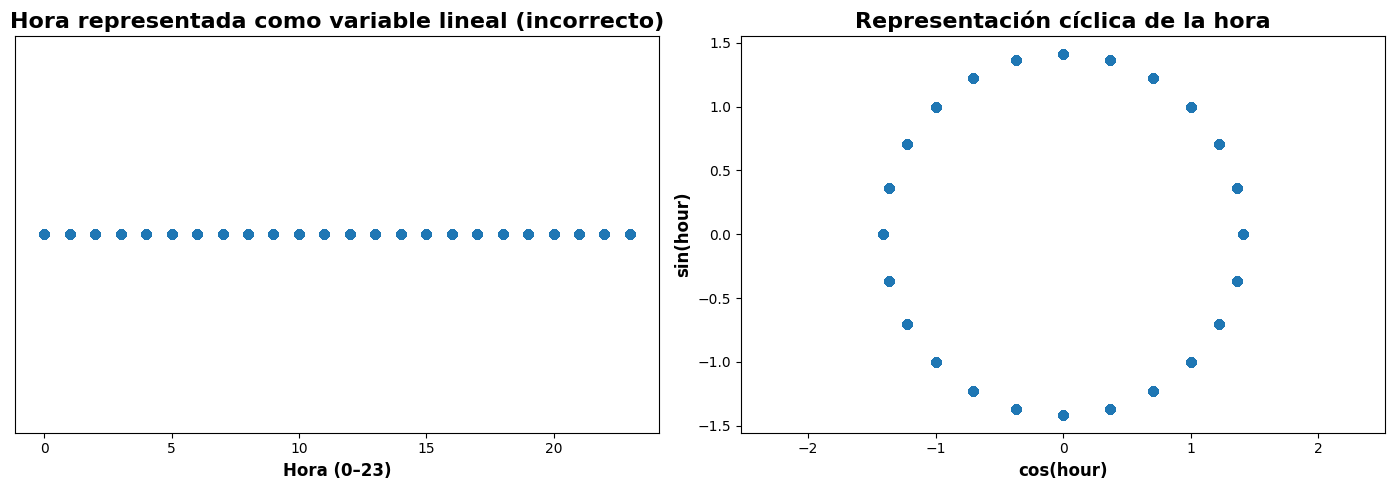

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Izquierda: SIN transformación
axes[0].scatter(
    data["hour"],
    np.zeros_like(data["hour"]),
    alpha=0.3
)
axes[0].set_yticks([])
axes[0].set_xlabel("Hora (0–23)", fontsize=12, fontweight="bold")
axes[0].set_title(
    "Hora representada como variable lineal (incorrecto)",
    fontsize=16,
    fontweight="bold"
)

# Derecha: CON transformación
axes[1].scatter(
    data_time["hour_cos"],
    data_time["hour_sin"],
    alpha=0.5
)
axes[1].set_title(
    "Representación cíclica de la hora",
    fontsize=16,
    fontweight="bold"
)
axes[1].set_xlabel("cos(hour)", fontsize=12, fontweight="bold")
axes[1].set_ylabel("sin(hour)", fontsize=12, fontweight="bold")
axes[1].axis("equal")

plt.tight_layout()
plt.show()


### 4.9 Tratamiento final

Aplicación del Pipeline y sus técnicas asociadas de acuerdo a los features creados, divididos en categóricas y numéricas segun las variables requeridas
- Numéricas : Winsorizer - Imputer - Scaler
- Categóricas : Imputer - OneHotEncoder

In [ ]:
# Pipeline numérico con Winsorizer
tratamiento_numericas = Pipeline(steps=[
    ("winsorizer", Winsorizer(limits=(0.05, 0.05))),
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

# Preprocesamiento categórico: imputación + one-hot encoding
tratamiento_categoricas = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

# Combina en un ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", tratamiento_numericas, features_num),
        ("cat", tratamiento_categoricas, features_cat),
        ("time", cyclical_features, ["hour", "month"])
    ]
)


## 5. "Foto" del Pipeline

Creación del Pipeline final, que junta el dataframe nuevo con ventanas y variables requeridas y la hora cíclica

In [ ]:
# Crea el pipeline final (preprocesamiento)
preprocesamiento = Pipeline(steps=[
    ("preprocessor", preprocessor)
])

Concatenación de cada dataframe agrupado que teníamos por localidad, para generar un dataframe final listo, donde no se mezclan los datos enrte localidades.

In [ ]:
# Concatenar todos los dataframes de dfs_por_localidad en un único dataframe
data_for_pipeline = pd.concat(dfs_por_localidad.values(), ignore_index=True)

# Aplicar el pipeline de preprocesamiento al dataframe combinado
X_preparada = preprocesamiento.fit_transform(data_for_pipeline)
X_preparada.shape

(33008, 51)

In [ ]:
# Composición del proceso
preprocesamiento

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('winsorizer',
                                                                   Winsorizer()),
                                                                  ('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['temperature_2m_actual',
                                                   'relative_humidity_2m_actual',
                                                   'cloud_cover_actual',
                                                   'temperature_2m_mean',
                                                   'temperature_2m_max',
                                                   'temperature_2m_min',
                                                   'relative_humidity_2m_mean',
                                                   'relative...
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['Localidad', 'is_day',
                                                   'is_rainy_hour', 'day']),
                                                 ('time',
                                                  ColumnTransformer(transformers=[('hour',
                                                                                   CyclicalFeatures(max_value=24),
                                                                                   ['hour']),
                                                                                  ('month',
                                                                                   CyclicalFeatures(max_value=12),
                                                                                   ['month'])]),
                                                  ['hour', 'month'])]))])

## 5. Data preparada

In [ ]:
pd.DataFrame(X_preparada)

,0,1,2,3,4,5,6,7,8,9,...,41,42,43,44,45,46,47,48,49,50
0,0.589208,-0.561102,-1.484396,0.804869,0.642428,0.944406,-0.842016,-1.041545,-0.635727,-1.635226,...,0.0,0.0,0.0,0.0,0.0,0.0,0.965926,-0.258819,5.000000e-01,0.866025
1,0.484369,-0.056782,-1.484396,0.710283,0.602846,0.827929,-0.752328,-0.530286,-0.635727,-1.635226,...,0.0,0.0,0.0,0.0,0.0,0.0,0.866025,-0.500000,5.000000e-01,0.866025
2,0.379530,0.576254,-1.484396,0.602798,0.503892,0.711452,-0.421597,0.239273,-0.635727,-1.635226,...,0.0,0.0,0.0,0.0,0.0,0.0,0.707107,-0.707107,5.000000e-01,0.866025
3,0.306143,0.849110,-1.484396,0.501762,0.404937,0.629918,-0.012989,0.570974,-0.453677,-1.635226,...,0.0,0.0,0.0,0.0,0.0,0.0,0.500000,-0.866025,5.000000e-01,0.866025
4,0.578724,0.393792,-1.484396,0.478116,0.305983,0.629918,0.257189,0.570974,-0.160589,-1.635226,...,0.0,0.0,0.0,0.0,0.0,0.0,0.258819,-0.965926,5.000000e-01,0.866025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33003,2.015015,-1.824701,0.880500,1.985052,1.994638,1.934459,-2.054359,-2.237867,-1.716447,-1.087762,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.500000,0.866025,-2.449294e-16,1.000000
33004,1.857757,-1.548220,0.904388,1.985052,1.994638,1.934459,-2.054359,-2.237867,-1.716447,-0.561355,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.258819,0.965926,-2.449294e-16,1.000000
33005,1.564208,-1.095305,0.044426,1.985052,1.849670,1.934459,-1.875604,-1.792779,-1.702748,-0.229718,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1.000000,-2.449294e-16,1.000000
33006,1.375498,-0.695991,-0.839424,1.841022,1.770507,1.817982,-1.554271,-1.307347,-1.633121,-0.092853,...,0.0,0.0,0.0,0.0,0.0,0.0,0.258819,0.965926,-2.449294e-16,1.000000


Ordenamiento de columnas para visualizar un poco mejor la data ya preparada

In [ ]:
num_cols = features_num
cat_cols = preprocesamiento.named_steps["preprocessor"] \
    .named_transformers_["cat"] \
    .named_steps["encoder"] \
    .get_feature_names_out(features_cat)

# Añadir los nombres de las columnas de la transformación cíclica
all_columns = list(num_cols) + list(cat_cols) + columns_name

data_preparada = pd.DataFrame(X_preparada, columns=all_columns)

In [ ]:
data_preparada.head()

,temperature_2m_actual,relative_humidity_2m_actual,cloud_cover_actual,temperature_2m_mean,temperature_2m_max,temperature_2m_min,relative_humidity_2m_mean,relative_humidity_2m_max,relative_humidity_2m_min,cloud_cover_mean,...,day_26,day_27,day_28,day_29,day_30,day_31,hour_sin,hour_cos,month_sin,month_cos
0,0.589208,-0.561102,-1.484396,0.804869,0.642428,0.944406,-0.842016,-1.041545,-0.635727,-1.635226,...,0.0,0.0,0.0,0.0,0.0,0.0,0.965926,-0.258819,0.5,0.866025
1,0.484369,-0.056782,-1.484396,0.710283,0.602846,0.827929,-0.752328,-0.530286,-0.635727,-1.635226,...,0.0,0.0,0.0,0.0,0.0,0.0,0.866025,-0.500000,0.5,0.866025
2,0.379530,0.576254,-1.484396,0.602798,0.503892,0.711452,-0.421597,0.239273,-0.635727,-1.635226,...,0.0,0.0,0.0,0.0,0.0,0.0,0.707107,-0.707107,0.5,0.866025
3,0.306143,0.849110,-1.484396,0.501762,0.404937,0.629918,-0.012989,0.570974,-0.453677,-1.635226,...,0.0,0.0,0.0,0.0,0.0,0.0,0.500000,-0.866025,0.5,0.866025
4,0.578724,0.393792,-1.484396,0.478116,0.305983,0.629918,0.257189,0.570974,-0.160589,-1.635226,...,0.0,0.0,0.0,0.0,0.0,0.0,0.258819,-0.965926,0.5,0.866025


Aquí se evidencia la data ya preparada en idioma computacional junto a la información de cada columna

In [ ]:
data_preparada.info()

NameError: name 'data_preparada' is not defined

Pasar el dataframe preparado ya a CSV

In [ ]:
data_preparada.to_csv('data_preparada_G3.csv', index=False)